# Plot

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import json

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disabpd.option_context('display.max_columns', 300)le copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [ ]:
# Load JSON
with open('chgchg_effs.json') as f:
    dataList = json.load(f)
rows = []
for i,data in enumerate(dataList):
    # Separate scalar fields and list-of-dicts fields
    scalar_fields = {k: v for k, v in data.items() if not isinstance(v, list)}
    list_fields   = {k: v for k, v in data.items() if isinstance(v, list)}

    for field, listOfDicts in list_fields.items():
        for d in listOfDicts:            
            row = scalar_fields.copy()
            row["index"] = i
            row.update(d)
            rows.append(row)

# Convert to DataFrame
df_c1c1 = pd.DataFrame(rows)
column_order = ['mLLP','tau_ns','tau0_ns']
column_order = column_order[:] + [col for col in df_c1c1.columns if col not in column_order[:]]

# Optional: set MultiIndex
df_c1c1 = df_c1c1[column_order]

### For each (mLLP,tau) keep only the entry with tau/tau0 closest to 1

In [ ]:
keep_indices = []
for group,df_g in df_c1c1.groupby(['mLLP','tau_ns']):
    imin = np.argmin(np.abs(1.0-df_g['tau_ns']/df_g['tau0_ns']))
    ii = df_g.index.to_list()[imin]
    keep_indices.append(ii)
df_c1c1 = df_c1c1[df_c1c1.index.isin(keep_indices)]
print(len(df_c1c1))

300


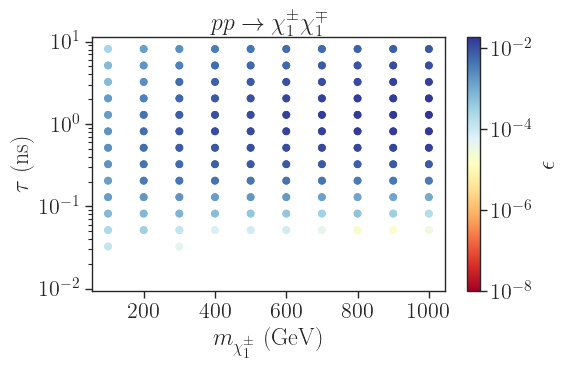

In [ ]:
plt.figure(figsize=(6,4))
x = df_c1c1['mLLP']
y = df_c1c1['tau_ns']
z = df_c1c1['EWK SR']

plt.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
plt.colorbar(label=r'$\epsilon$')
plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
# plt.title(r'$ g g \to \bar{t} t$',fontsize=20)

plt.title(r'$p p \to \chi_1^\pm \chi_1^\mp$')
plt.tight_layout()
plt.show()

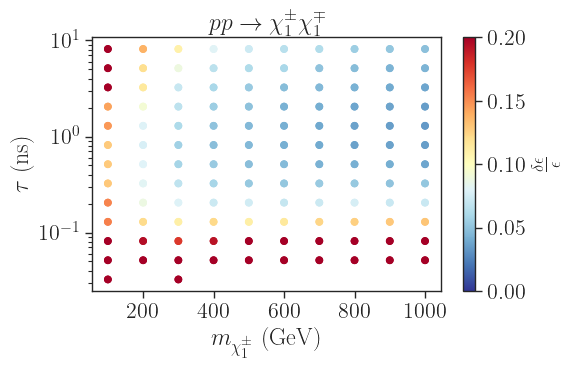

In [ ]:
plt.figure(figsize=(6,4))
x = df_c1c1['mLLP']
y = df_c1c1['tau_ns']
z = df_c1c1['EWK SR Error']/df_c1c1['EWK SR']

plt.scatter(x,y,c=z,cmap=cm_rev,vmin=0,vmax=0.2)
plt.colorbar(label=r'$\frac{\delta \epsilon}{\epsilon}$')
plt.yscale('log')
plt.ylabel(r'$\tau$ (ns)')
plt.xlabel(r'$m_{\chi_1^\pm}$ (GeV)')
# plt.title(r'$ g g \to \bar{t} t$',fontsize=20)

plt.title(r'$p p \to \chi_1^\pm \chi_1^\mp$')
plt.tight_layout()
plt.show()

In [ ]:
df_bigErrors = df_c1c1[((df_c1c1['EWK SR Error']/df_c1c1['EWK SR']) > 0.1) | (df_c1c1['EWK SR'] == 0.0)]

In [78]:
df_bigErrors['rel_error'] = df_bigErrors['EWK SR Error']/df_bigErrors['EWK SR']
target_error = 0.1
df_bigErrors['New N'] = df_bigErrors['Number of Events']*((df_bigErrors['rel_error']/target_error)**2)
df_bigErrors['New N'] = df_bigErrors['New N'].fillna(1e5)

In [92]:
more_evts = []
all_evts = []
for mLLP in df_bigErrors['mLLP'].unique():
    df_rest = df_bigErrors[df_bigErrors['mLLP'] == mLLP]
    for tau0 in df_rest['tau0_ns'].unique():
        all_evts.append((mLLP,tau0))
        df_rest2 = df_rest[df_rest['tau0_ns'] == tau0]
        max_nevt = int(min(1e5,max(df_rest2['New N'])))
        if max_nevt < df_rest2['Number of Events'].iloc[0]:
            continue
        # print(mLLP,tau0,max_nevt)
        more_evts.append((mLLP,tau0,max_nevt))


In [83]:
print(len(more_evts))

73


In [91]:
print([tuple(x) for x in np.array(more_evts)[:,:2].tolist()])

[(100.0, 0.012924467857206674), (100.0, 0.02048389917698675), (100.0, 0.03246479345625866), (100.0, 0.051453242269060694), (100.0, 0.08154786978348456), (100.0, 0.12924467857206676), (100.0, 0.20483899176986753), (100.0, 0.32464793456258656), (100.0, 0.514532422690607), (100.0, 0.8154786978348457), (100.0, 1.2924467857206674), (100.0, 2.048389917698675), (100.0, 3.2464793456258656), (100.0, 5.145324226906069), (100.0, 8.154786978348458), (800.0, 0.012924467857206674), (800.0, 0.02048389917698675), (800.0, 0.03246479345625866), (800.0, 0.051453242269060694), (800.0, 0.08154786978348456), (800.0, 0.12924467857206676), (900.0, 0.012924467857206674), (900.0, 0.02048389917698675), (900.0, 0.03246479345625866), (900.0, 0.051453242269060694), (900.0, 0.08154786978348456), (900.0, 0.12924467857206676), (1000.0, 0.012924467857206674), (1000.0, 0.02048389917698675), (1000.0, 0.03246479345625866), (1000.0, 0.051453242269060694), (1000.0, 0.08154786978348456), (1000.0, 0.12924467857206676), (200.0